In [1]:

import numpy as np 
import pandas as pd 


In [2]:
print("Hello Kaggle")


Hello Kaggle


In [4]:
import os

print(os.listdir("/kaggle/input"))

['datasets']


In [5]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    print(root)
    

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/grassknoted
/kaggle/input/datasets/grassknoted/asl-alphabet
/kaggle/input/datasets/grassknoted/asl-alphabet/asl_alphabet_test
/kaggle/input/datasets/grassknoted/asl-alphabet/asl_alphabet_test/asl_alphabet_test
/kaggle/input/datasets/grassknoted/asl-alphabet/asl_alphabet_train
/kaggle/input/datasets/grassknoted/asl-alphabet/asl_alphabet_train/asl_alphabet_train
/kaggle/input/datasets/grassknoted/asl-alphabet/asl_alphabet_train/asl_alphabet_train/N
/kaggle/input/datasets/grassknoted/asl-alphabet/asl_alphabet_train/asl_alphabet_train/R
/kaggle/input/datasets/grassknoted/asl-alphabet/asl_alphabet_train/asl_alphabet_train/space
/kaggle/input/datasets/grassknoted/asl-alphabet/asl_alphabet_train/asl_alphabet_train/B
/kaggle/input/datasets/grassknoted/asl-alphabet/asl_alphabet_train/asl_alphabet_train/I
/kaggle/input/datasets/grassknoted/asl-alphabet/asl_alphabet_train/asl_alphabet_train/del
/kaggle/input/datasets/grassknoted/asl-alph

In [6]:
import os

TRAIN_PATH = "/kaggle/input/datasets/grassknoted/asl-alphabet/asl_alphabet_train/asl_alphabet_train"

classes = sorted(os.listdir(TRAIN_PATH))

print("Total Classes:", len(classes))
print(classes)

Total Classes: 29
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


In [7]:
for cls in sorted(os.listdir(TRAIN_PATH)):
    
    folder = os.path.join(TRAIN_PATH, cls)

    print(
        cls,
        len(os.listdir(folder))
    )

A 3000
B 3000
C 3000
D 3000
E 3000
F 3000
G 3000
H 3000
I 3000
J 3000
K 3000
L 3000
M 3000
N 3000
O 3000
P 3000
Q 3000
R 3000
S 3000
T 3000
U 3000
V 3000
W 3000
X 3000
Y 3000
Z 3000
del 3000
nothing 3000
space 3000


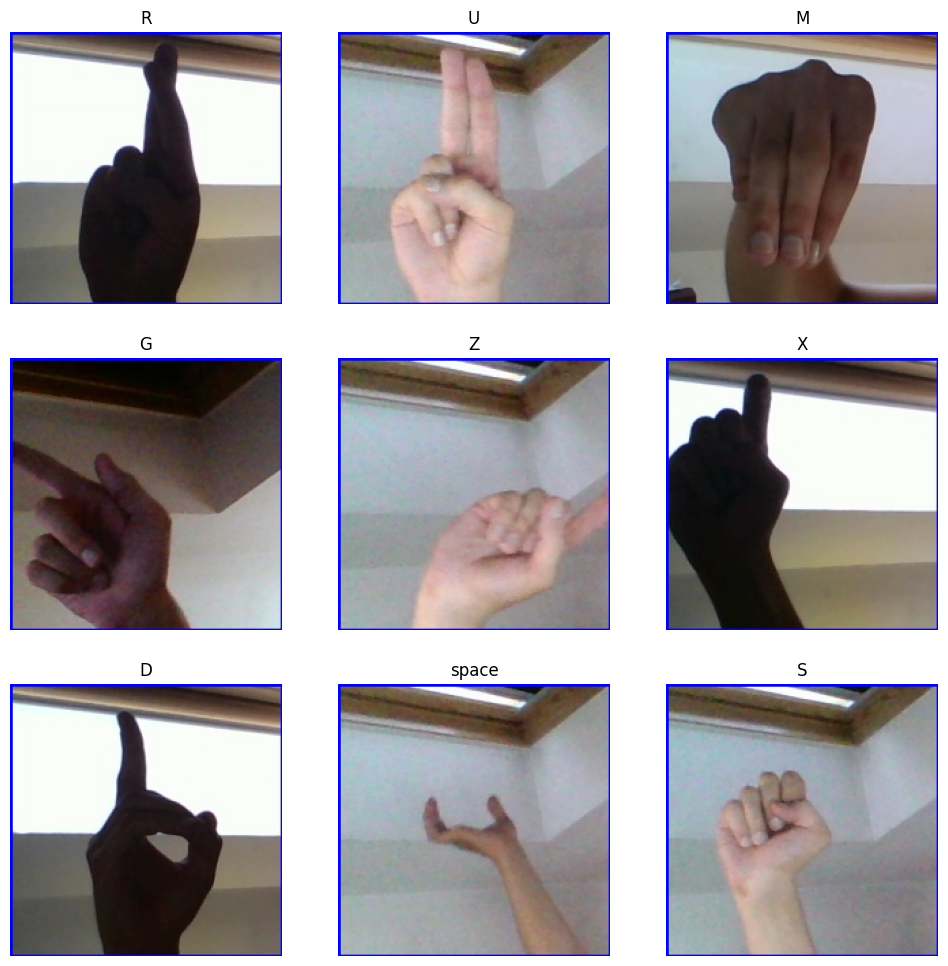

In [8]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

plt.figure(figsize=(12,12))

for i in range(9):

    cls = random.choice(classes)

    img_name = random.choice(
        os.listdir(
            os.path.join(TRAIN_PATH, cls)
        )
    )

    img_path = os.path.join(
        TRAIN_PATH,
        cls,
        img_name
    )

    img = Image.open(img_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

In [9]:
import pandas as pd
import os

TRAIN_PATH = "/kaggle/input/datasets/grassknoted/asl-alphabet/asl_alphabet_train/asl_alphabet_train"

data = []

for label in os.listdir(TRAIN_PATH):

    folder = os.path.join(TRAIN_PATH, label)

    for img in os.listdir(folder):

        data.append([
            os.path.join(folder, img),
            label
        ])

df = pd.DataFrame(
    data,
    columns=["filepath", "label"]
)

print(df.head())
print("\nTotal Images:", len(df))

                                            filepath label
0  /kaggle/input/datasets/grassknoted/asl-alphabe...     N
1  /kaggle/input/datasets/grassknoted/asl-alphabe...     N
2  /kaggle/input/datasets/grassknoted/asl-alphabe...     N
3  /kaggle/input/datasets/grassknoted/asl-alphabe...     N
4  /kaggle/input/datasets/grassknoted/asl-alphabe...     N

Total Images: 87000


In [10]:
print(df["label"].value_counts())


label
N          3000
R          3000
space      3000
B          3000
I          3000
del        3000
F          3000
H          3000
E          3000
U          3000
M          3000
X          3000
K          3000
Q          3000
Y          3000
S          3000
G          3000
A          3000
O          3000
T          3000
V          3000
Z          3000
C          3000
P          3000
L          3000
W          3000
D          3000
nothing    3000
J          3000
Name: count, dtype: int64


In [11]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 60900
Validation: 13050
Test: 13050


In [12]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

2026-06-11 04:29:17.587384: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781152157.823965      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781152157.890119      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781152158.449042      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781152158.449104      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781152158.449107      58 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [13]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

train_df["label_encoded"] = encoder.fit_transform(train_df["label"])
val_df["label_encoded"] = encoder.transform(val_df["label"])
test_df["label_encoded"] = encoder.transform(test_df["label"])

NUM_CLASSES = len(encoder.classes_)

print(NUM_CLASSES)
print(encoder.classes_)

29
['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z' 'del' 'nothing' 'space']


In [14]:
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 64

In [15]:
from tensorflow.keras.applications.resnet50 import preprocess_input

def load_image(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE]
    )

    image = preprocess_input(image)

    return image, label

In [16]:
def create_dataset(df, training=False):

    ds = tf.data.Dataset.from_tensor_slices(
        (
            df["filepath"].values,
            df["label_encoded"].values
        )
    )

    ds = ds.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if training:
        ds = ds.shuffle(10000)

    ds = ds.batch(BATCH_SIZE)

    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds

In [18]:
train_ds = create_dataset(
    train_df,
    training=True
)

val_ds = create_dataset(
    val_df
)

test_ds = create_dataset(
    test_df
)

In [19]:
train_ds = create_dataset(train_df)

val_ds = create_dataset(val_df)

test_ds = create_dataset(test_df)

In [30]:
print(train_df["label_encoded"].min())
print(train_df["label_encoded"].max())
print(NUM_CLASSES)

0
28
29


In [31]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels.shape)

(64, 224, 224, 3)
(64,)


In [33]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

In [34]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([

    layers.RandomRotation(0.05),

    layers.RandomZoom(0.05),

    layers.RandomContrast(0.05)

])

In [36]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

In [37]:
inputs = tf.keras.Input(shape=(224,224,3))

x = data_augmentation(inputs)

x = base_model(
    x,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dense(
    512,
    activation="relu"
)(x)

x = tf.keras.layers.Dropout(0.4)(x)

outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

resnet_model = tf.keras.Model(
    inputs,
    outputs
)

In [39]:
resnet_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

In [40]:
from tensorflow.keras.callbacks import *

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True
)

checkpoint = ModelCheckpoint(

    "best_resnet.keras",

    save_best_only=True,

    monitor="val_accuracy"
)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.2,

    patience=2,

    verbose=1
)

In [41]:
history = resnet_model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=3,

    callbacks=[
        early_stop,
        checkpoint,
        reduce_lr
    ]
)

Epoch 1/3


I0000 00:00:1781153009.149940     162 cuda_dnn.cc:529] Loaded cuDNN version 91002


952/952 ━━━━━━━━━━━━━━━━━━━━ 304s 305ms/step - accuracy: 0.6963 - loss: 1.0049 - val_accuracy: 0.6108 - val_loss: 1.2572 - learning_rate: 0.0010
Epoch 2/3
952/952 ━━━━━━━━━━━━━━━━━━━━ 286s 300ms/step - accuracy: 0.8289 - loss: 0.5281 - val_accuracy: 0.6769 - val_loss: 1.0575 - learning_rate: 0.0010
Epoch 3/3
952/952 ━━━━━━━━━━━━━━━━━━━━ 286s 300ms/step - accuracy: 0.8613 - loss: 0.4223 - val_accuracy: 0.6864 - val_loss: 1.0327 - learning_rate: 0.0010


In [42]:
print(
    "Best Train Accuracy:",
    max(history.history["accuracy"])
)

print(
    "Best Validation Accuracy:",
    max(history.history["val_accuracy"])
)

Best Train Accuracy: 0.8613300323486328
Best Validation Accuracy: 0.6863601803779602


In [43]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [44]:
count = 0

for layer in base_model.layers:
    if layer.trainable:
        count += 1

print("Trainable Layers:", count)

Trainable Layers: 30


In [45]:
resnet_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

In [46]:
history_finetune = resnet_model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=5
)

Epoch 1/5
952/952 ━━━━━━━━━━━━━━━━━━━━ 385s 392ms/step - accuracy: 0.9048 - loss: 0.2920 - val_accuracy: 0.7372 - val_loss: 0.9521
Epoch 2/5
952/952 ━━━━━━━━━━━━━━━━━━━━ 370s 389ms/step - accuracy: 0.9518 - loss: 0.1479 - val_accuracy: 0.7585 - val_loss: 0.9098
Epoch 3/5
952/952 ━━━━━━━━━━━━━━━━━━━━ 370s 389ms/step - accuracy: 0.9661 - loss: 0.1031 - val_accuracy: 0.7738 - val_loss: 0.8636
Epoch 4/5
952/952 ━━━━━━━━━━━━━━━━━━━━ 370s 389ms/step - accuracy: 0.9742 - loss: 0.0774 - val_accuracy: 0.8018 - val_loss: 0.7466
Epoch 5/5
952/952 ━━━━━━━━━━━━━━━━━━━━ 371s 389ms/step - accuracy: 0.9806 - loss: 0.0588 - val_accuracy: 0.8098 - val_loss: 0.7339


In [47]:
print(
    "Best Fine-Tuned Train Accuracy:",
    max(history_finetune.history["accuracy"])
)

print(
    "Best Fine-Tuned Validation Accuracy:",
    max(history_finetune.history["val_accuracy"])
)

Best Fine-Tuned Train Accuracy: 0.9806404113769531
Best Fine-Tuned Validation Accuracy: 0.8098084330558777


In [48]:
resnet_model.save("resnet50_finetuned.keras")

In [49]:
import os

for file in os.listdir():
    if "resnet" in file.lower():
        print(file)

best_resnet.keras
resnet50_finetuned.keras


In [50]:
test_loss, test_acc = resnet_model.evaluate(
    test_ds
)

print("Test Accuracy:", test_acc)

204/204 ━━━━━━━━━━━━━━━━━━━━ 50s 246ms/step - accuracy: 0.8011 - loss: 0.7604
Test Accuracy: 0.8010727763175964


In [51]:
import numpy as np

predictions = resnet_model.predict(test_ds)

y_pred = np.argmax(
    predictions,
    axis=1
)

204/204 ━━━━━━━━━━━━━━━━━━━━ 54s 254ms/step


In [52]:
y_true = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

print(len(y_true))
print(len(y_pred))

13050
13050


In [53]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

           A       0.82      0.77      0.80       450
           B       0.91      0.84      0.87       450
           C       0.96      0.98      0.97       450
           D       0.97      0.82      0.89       450
           E       0.90      0.23      0.36       450
           F       0.97      0.88      0.93       450
           G       0.94      0.66      0.78       450
           H       0.92      0.43      0.59       450
           I       1.00      0.48      0.65       450
           J       0.87      0.48      0.61       450
           K       0.90      0.78      0.84       450
           L       0.90      0.80      0.85       450
           M       0.74      0.74      0.74       450
           N       0.45      0.98      0.62       450
           O       0.76      0.96      0.85       450
           P       0.91      0.98      0.94       450
           Q       0.89      0.97      0.93       450
           R       0.66    

In [54]:
from sklearn.metrics import *

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.8010727969348659
Precision: 0.8444040369518916
Recall   : 0.8010727969348659
F1 Score : 0.7975541585956546


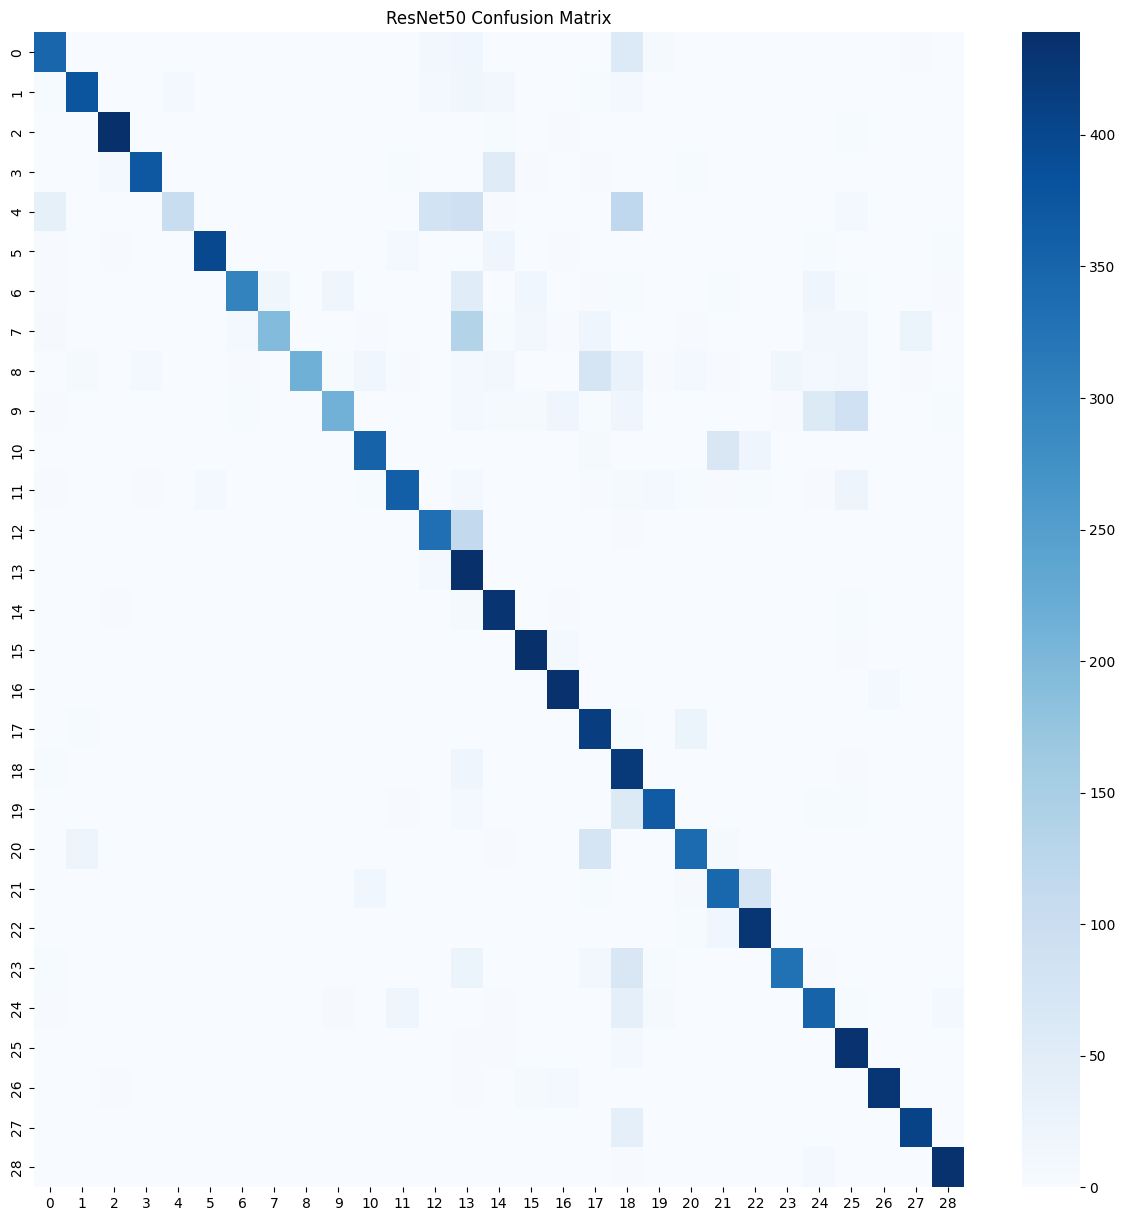

In [55]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(15,15))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title("ResNet50 Confusion Matrix")

plt.show()

In [56]:
resnet_model.save(
    "resnet50_finetuned.keras"
)

In [57]:
import os

for file in os.listdir():
    if ".keras" in file:
        print(file)

best_resnet.keras
resnet50_finetuned.keras


In [ ]:
// now we are going to use our 2nd model  which is # Model 2: EfficientNetB0//

In [58]:
from tensorflow.keras.applications.efficientnet import preprocess_input

def load_image_eff(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE]
    )

    image = preprocess_input(image)

    return image, label

In [59]:
def create_dataset_eff(df, training=False):

    ds = tf.data.Dataset.from_tensor_slices(
        (
            df["filepath"].values,
            df["label_encoded"].values
        )
    )

    ds = ds.map(
        load_image_eff,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if training:
        ds = ds.shuffle(10000)

    ds = ds.batch(BATCH_SIZE)

    ds = ds.prefetch(
        tf.data.AUTOTUNE
    )

    return ds

In [60]:
train_ds_eff = create_dataset_eff(
    train_df,
    training=True
)

val_ds_eff = create_dataset_eff(
    val_df
)

test_ds_eff = create_dataset_eff(
    test_df
)

In [61]:
for images, labels in train_ds_eff.take(1):
    print(images.shape)
    print(labels.shape)

(64, 224, 224, 3)
(64,)


In [62]:
from tensorflow.keras.applications import EfficientNetB0

In [63]:
base_model_eff = EfficientNetB0(

    weights="imagenet",

    include_top=False,

    input_shape=(224,224,3)
)

base_model_eff.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [65]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([

    layers.RandomRotation(0.05),

    layers.RandomZoom(0.05),

    layers.RandomContrast(0.05)

])

In [66]:
inputs = tf.keras.Input(
    shape=(224,224,3)
)

x = data_augmentation(inputs)

x = base_model_eff(
    x,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dense(
    512,
    activation="relu"
)(x)

x = tf.keras.layers.Dropout(0.4)(x)

outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

efficientnet_model = tf.keras.Model(
    inputs,
    outputs
)

In [67]:
efficientnet_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

In [68]:
early_stop
checkpoint
reduce_lr

In [69]:
history_eff = efficientnet_model.fit(

    train_ds_eff,

    validation_data=val_ds_eff,

    epochs=3,

    callbacks=[
        early_stop,
        checkpoint,
        reduce_lr
    ]
)

Epoch 1/3


E0000 00:00:1781157110.718448      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_5_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


952/952 ━━━━━━━━━━━━━━━━━━━━ 185s 176ms/step - accuracy: 0.8541 - loss: 0.5031 - val_accuracy: 0.9796 - val_loss: 0.0721 - learning_rate: 0.0010
Epoch 2/3
952/952 ━━━━━━━━━━━━━━━━━━━━ 168s 170ms/step - accuracy: 0.9535 - loss: 0.1483 - val_accuracy: 0.9837 - val_loss: 0.0487 - learning_rate: 0.0010
Epoch 3/3
952/952 ━━━━━━━━━━━━━━━━━━━━ 170s 172ms/step - accuracy: 0.9639 - loss: 0.1105 - val_accuracy: 0.9881 - val_loss: 0.0350 - learning_rate: 0.0010


In [70]:
print(
    "Frozen Train Accuracy:",
    max(history_eff.history["accuracy"])
)

print(
    "Frozen Validation Accuracy:",
    max(history_eff.history["val_accuracy"])
)

Frozen Train Accuracy: 0.9639244675636292
Frozen Validation Accuracy: 0.9881225824356079


In [71]:
test_loss, test_acc = efficientnet_model.evaluate(
    test_ds_eff
)

print("Test Accuracy:", test_acc)

204/204 ━━━━━━━━━━━━━━━━━━━━ 27s 134ms/step - accuracy: 0.9887 - loss: 0.0366
Test Accuracy: 0.9886590242385864


In [73]:
efficientnet_model.save(
    "efficientnetb0_frozen.keras"
)

In [74]:
import os

for file in os.listdir():
    if ".keras" in file:
        print(file)

best_resnet.keras
efficientnetb0_frozen.keras
resnet50_finetuned.keras


In [75]:
import numpy as np

predictions = efficientnet_model.predict(
    test_ds_eff
)

y_pred = np.argmax(
    predictions,
    axis=1
)

204/204 ━━━━━━━━━━━━━━━━━━━━ 32s 145ms/step


In [76]:
y_true = []

for images, labels in test_ds_eff:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

In [77]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

           A       1.00      0.99      0.99       450
           B       1.00      1.00      1.00       450
           C       1.00      1.00      1.00       450
           D       1.00      1.00      1.00       450
           E       1.00      0.95      0.97       450
           F       1.00      0.99      1.00       450
           G       1.00      1.00      1.00       450
           H       1.00      1.00      1.00       450
           I       0.99      0.98      0.99       450
           J       0.99      0.99      0.99       450
           K       1.00      0.94      0.97       450
           L       1.00      1.00      1.00       450
           M       1.00      0.96      0.98       450
           N       0.96      1.00      0.98       450
           O       1.00      1.00      1.00       450
           P       1.00      1.00      1.00       450
           Q       1.00      1.00      1.00       450
           R       0.97    

In [78]:
from sklearn.metrics import *

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9886590038314176
Precision: 0.988959479415365
Recall   : 0.9886590038314176
F1 Score : 0.9886740080883735


In [79]:
resnet_model.save("resnet50_finetuned.keras")
efficientnet_model.save("efficientnetb0_finetuned.keras")

In [ ]:
//now we will continue this on the MobileNetV2 model

In [80]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def load_image_mobile(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE]
    )

    image = preprocess_input(image)

    return image, label

In [81]:
def create_dataset_mobile(df, training=False):

    ds = tf.data.Dataset.from_tensor_slices(
        (
            df["filepath"].values,
            df["label_encoded"].values
        )
    )

    ds = ds.map(
        load_image_mobile,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if training:
        ds = ds.shuffle(10000)

    ds = ds.batch(BATCH_SIZE)

    ds = ds.prefetch(
        tf.data.AUTOTUNE
    )

    return ds

In [82]:
train_ds_mobile = create_dataset_mobile(
    train_df,
    training=True
)

val_ds_mobile = create_dataset_mobile(
    val_df
)

test_ds_mobile = create_dataset_mobile(
    test_df
)

In [83]:
for images, labels in train_ds_mobile.take(1):
    print(images.shape)
    print(labels.shape)

(64, 224, 224, 3)
(64,)


In [84]:
from tensorflow.keras.applications import MobileNetV2

In [85]:
base_model_mobile = MobileNetV2(

    weights="imagenet",

    include_top=False,

    input_shape=(224,224,3)
)

base_model_mobile.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [86]:
inputs = tf.keras.Input(
    shape=(224,224,3)
)

x = data_augmentation(inputs)

x = base_model_mobile(
    x,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dense(
    512,
    activation="relu"
)(x)

x = tf.keras.layers.Dropout(0.4)(x)

outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

mobilenet_model = tf.keras.Model(
    inputs,
    outputs
)

In [87]:
mobilenet_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

In [88]:
history_mobile = mobilenet_model.fit(

    train_ds_mobile,

    validation_data=val_ds_mobile,

    epochs=3,

    callbacks=[
        early_stop,
        checkpoint,
        reduce_lr
    ]
)

Epoch 1/3
952/952 ━━━━━━━━━━━━━━━━━━━━ 139s 131ms/step - accuracy: 0.7119 - loss: 0.9636 - val_accuracy: 0.6117 - val_loss: 1.3804 - learning_rate: 0.0010
Epoch 2/3
952/952 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.8347 - loss: 0.5267
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
952/952 ━━━━━━━━━━━━━━━━━━━━ 130s 128ms/step - accuracy: 0.8476 - loss: 0.4809 - val_accuracy: 0.6006 - val_loss: 1.5398 - learning_rate: 0.0010
Epoch 3/3
952/952 ━━━━━━━━━━━━━━━━━━━━ 130s 129ms/step - accuracy: 0.9003 - loss: 0.3119 - val_accuracy: 0.6018 - val_loss: 1.5847 - learning_rate: 2.0000e-04


In [89]:
print(
    "Frozen Train Accuracy:",
    max(history_mobile.history["accuracy"])
)

print(
    "Frozen Validation Accuracy:",
    max(history_mobile.history["val_accuracy"])
)

Frozen Train Accuracy: 0.9003283977508545
Frozen Validation Accuracy: 0.6117241382598877


In [90]:
base_model_mobile.trainable = True

for layer in base_model_mobile.layers[:-30]:
    layer.trainable = False

In [91]:
mobilenet_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

In [92]:
history_mobile_ft = mobilenet_model.fit(

    train_ds_mobile,

    validation_data=val_ds_mobile,

    epochs=5
)

Epoch 1/5
952/952 ━━━━━━━━━━━━━━━━━━━━ 173s 162ms/step - accuracy: 0.7900 - loss: 0.6920 - val_accuracy: 0.6535 - val_loss: 1.3041
Epoch 2/5
952/952 ━━━━━━━━━━━━━━━━━━━━ 158s 156ms/step - accuracy: 0.8853 - loss: 0.3616 - val_accuracy: 0.6963 - val_loss: 1.1018
Epoch 3/5
952/952 ━━━━━━━━━━━━━━━━━━━━ 162s 160ms/step - accuracy: 0.9172 - loss: 0.2656 - val_accuracy: 0.7299 - val_loss: 0.9539
Epoch 4/5
952/952 ━━━━━━━━━━━━━━━━━━━━ 157s 156ms/step - accuracy: 0.9323 - loss: 0.2169 - val_accuracy: 0.7491 - val_loss: 0.8852
Epoch 5/5
952/952 ━━━━━━━━━━━━━━━━━━━━ 157s 156ms/step - accuracy: 0.9436 - loss: 0.1767 - val_accuracy: 0.7576 - val_loss: 0.8572


In [93]:
print(
    "Fine-Tuned Train Accuracy:",
    max(history_mobile_ft.history["accuracy"])
)

print(
    "Fine-Tuned Validation Accuracy:",
    max(history_mobile_ft.history["val_accuracy"])
)

Fine-Tuned Train Accuracy: 0.9436289072036743
Fine-Tuned Validation Accuracy: 0.7576245069503784


In [94]:
mobilenet_model.save(
    "mobilenetv2_finetuned.keras"
)

In [95]:
test_loss, test_acc = mobilenet_model.evaluate(
    test_ds_mobile
)

print("Test Accuracy:", test_acc)

204/204 ━━━━━━━━━━━━━━━━━━━━ 19s 94ms/step - accuracy: 0.7548 - loss: 0.8566
Test Accuracy: 0.7547892928123474


In [96]:
import numpy as np
from sklearn.metrics import classification_report

predictions = efficientnet_model.predict(test_ds_eff)

y_pred = np.argmax(predictions, axis=1)

y_true = []

for images, labels in test_ds_eff:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=encoder.classes_
    )
)

204/204 ━━━━━━━━━━━━━━━━━━━━ 27s 134ms/step
              precision    recall  f1-score   support

           A       1.00      0.99      0.99       450
           B       1.00      1.00      1.00       450
           C       1.00      1.00      1.00       450
           D       1.00      1.00      1.00       450
           E       1.00      0.95      0.97       450
           F       1.00      0.99      1.00       450
           G       1.00      1.00      1.00       450
           H       1.00      1.00      1.00       450
           I       0.99      0.98      0.99       450
           J       0.99      0.99      0.99       450
           K       1.00      0.94      0.97       450
           L       1.00      1.00      1.00       450
           M       1.00      0.96      0.98       450
           N       0.96      1.00      0.98       450
           O       1.00      1.00      1.00       450
           P       1.00      1.00      1.00       450
           Q       1.00      1.00    

In [97]:
from sklearn.metrics import *

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9886590038314176
Precision: 0.988959479415365
Recall   : 0.9886590038314176
F1 Score : 0.9886740080883735


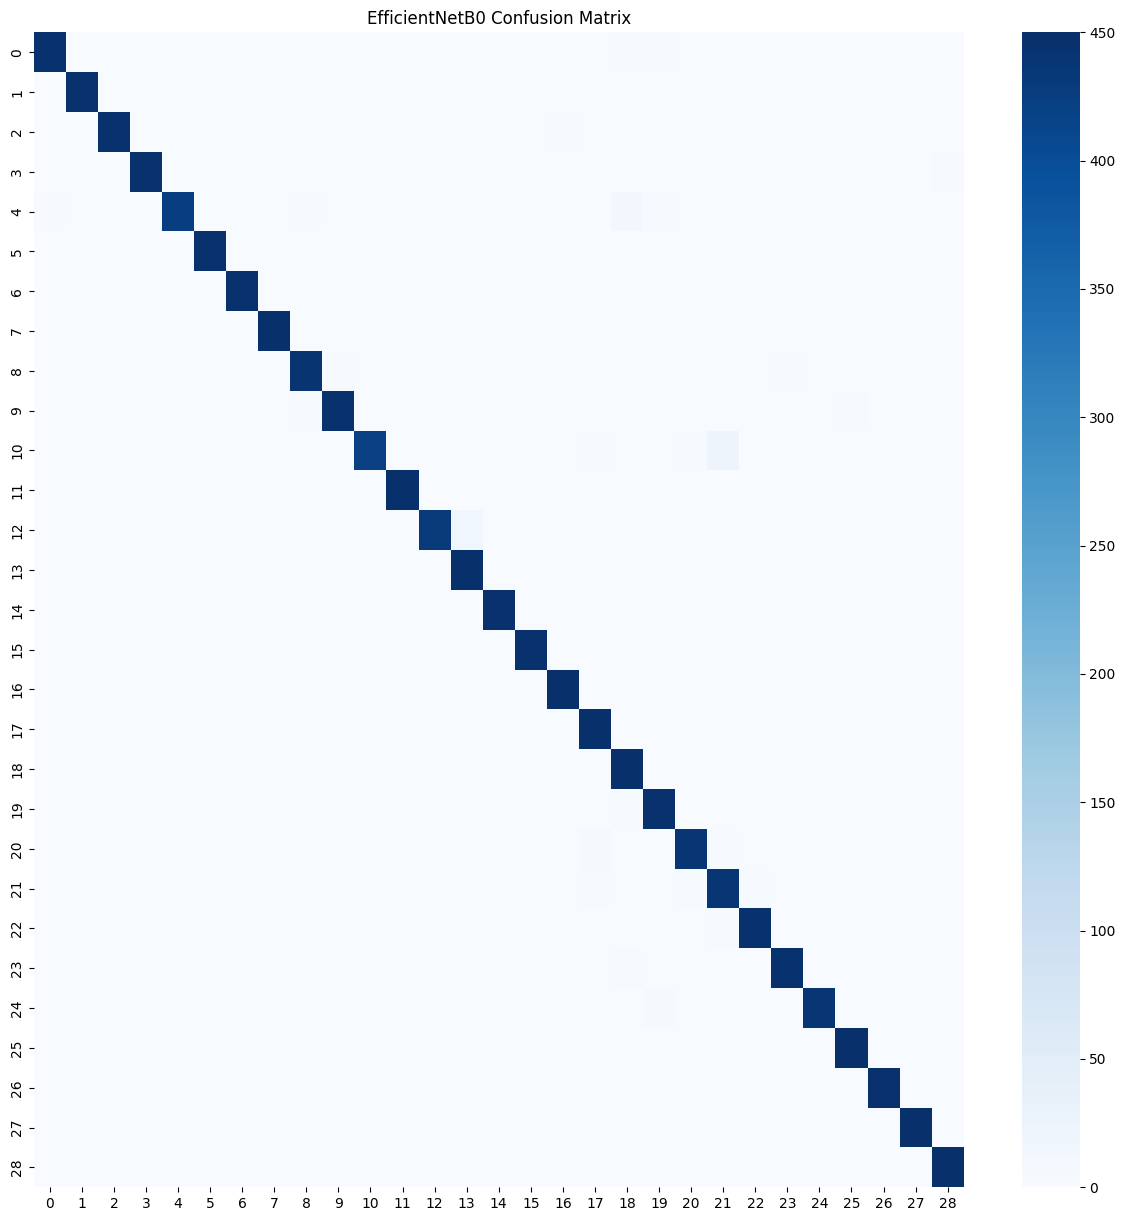

In [98]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(15,15))

sns.heatmap(cm, cmap="Blues")

plt.title("EfficientNetB0 Confusion Matrix")

plt.show()